In [1]:
!pip install transformers
!pip install torch
!pip install nltk
!pip install datasets
!pip install spacy
!pip install gensim
!pip install scikit-learn
!pip install sentence-transformers
!pip install streamlit
!pip install pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 96.5 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
import spacy
import re

from nltk.corpus import stopwords

from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

from collections import Counter

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics.pairwise import cosine_similarity

from gensim.models import Word2Vec

from sentence_transformers import SentenceTransformer
from transformers import pipeline
from transformers import AutoTokenizer

In [5]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [6]:
data = {
    "theme":[
        "love",
        "nature",
        "darkness",
        "friendship",
        "dreams",
        "rain",
        "moon",
        "war",
        "hope",
        "loneliness"
    ],

    "poem":[
         "Love blooms softly in silent hearts",

        "The trees whisper beneath the stars",

        "Dark shadows dance through empty halls",

        "Friends remain through stormy nights",

        "Dreams fly beyond the endless sky",

        "Rain sings gently on lonely roads",

        "The moon watches the silent ocean",

        "War burns the soul of humanity",

        "Hope rises after every storm",

        "Loneliness echoes through the night"
    ],

    "style":[
        "romantic",
        "nature",
        "dark",
        "motivational",
        "fantasy",
        "melancholy",
        "mystical",
        "historical",
        "inspirational",
        "sad"
    ]
}

poem_df = pd.DataFrame(data)
poem_df.head()

,theme,poem,style
0,love,Love blooms softly in silent hearts,romantic
1,nature,The trees whisper beneath the stars,nature
2,darkness,Dark shadows dance through empty halls,dark
3,friendship,Friends remain through stormy nights,motivational
4,dreams,Dreams fly beyond the endless sky,fantasy


In [7]:
poem_df.shape

(10, 3)

In [8]:
poem_df.isnull().sum()

,0
theme,0
poem,0
style,0


In [9]:
poem_df['style'].value_counts()

,count
style,
romantic,1
nature,1
dark,1
motivational,1
fantasy,1
melancholy,1
mystical,1
historical,1
inspirational,1


In [10]:
poem_df['poem_length'] = poem_df['poem'].apply(len)

In [11]:
poem_df['poem_length'].describe()

,poem_length
count,10.00000
mean,33.60000
std,2.91357
min,28.00000
25%,33.00000
50%,34.00000
75%,35.00000
max,38.00000


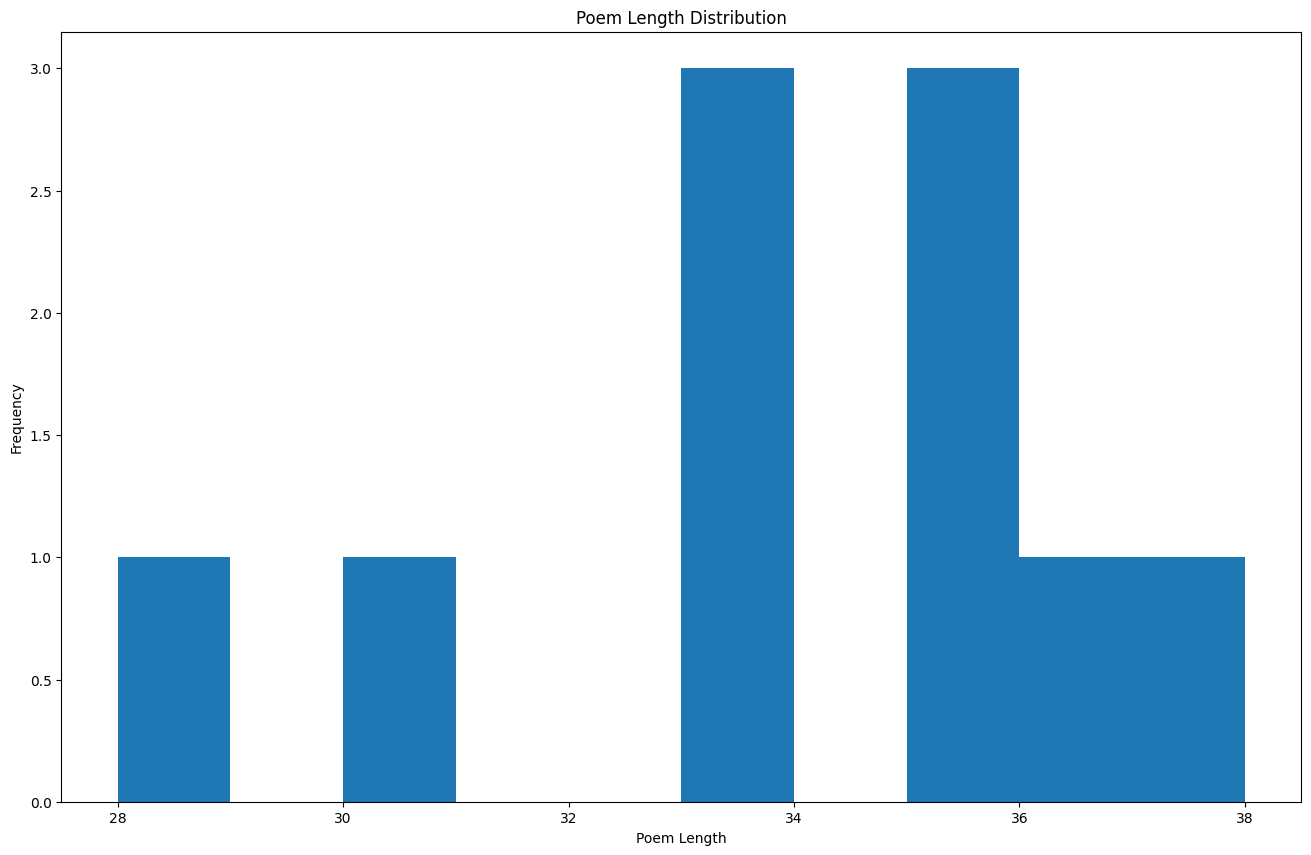

In [12]:
plt.figure(figsize=(16,10))

plt.hist(poem_df['poem_length'])
plt.title('Poem Length Distribution')
plt.xlabel('Poem Length')
plt.ylabel('Frequency')
plt.show()

In [13]:
poem_df['clean_poem'] = poem_df['poem'].str.lower()

In [14]:
poem_df.head()

,theme,poem,style,poem_length,clean_poem
0,love,Love blooms softly in silent hearts,romantic,35,love blooms softly in silent hearts
1,nature,The trees whisper beneath the stars,nature,35,the trees whisper beneath the stars
2,darkness,Dark shadows dance through empty halls,dark,38,dark shadows dance through empty halls
3,friendship,Friends remain through stormy nights,motivational,36,friends remain through stormy nights
4,dreams,Dreams fly beyond the endless sky,fantasy,33,dreams fly beyond the endless sky


In [15]:
def clean_text(text):
  text = re.sub(r'[^a-zA-Z\\s]','',text)
  return text

poem_df['clean_poem'] = poem_df['clean_poem'].apply(clean_text)

In [16]:
poem_df['clean_poem'] = poem_df['clean_poem'].apply(
    lambda x : re.sub(r'\\s+',' ',x)
)

In [17]:
poem_df['tokens'] = poem_df['clean_poem'].apply(
    lambda x : x.split()
)

In [18]:
poem_df.head()

,theme,poem,style,poem_length,clean_poem,tokens
0,love,Love blooms softly in silent hearts,romantic,35,lovebloomssoftlyinsilenthearts,[lovebloomssoftlyinsilenthearts]
1,nature,The trees whisper beneath the stars,nature,35,thetreeswhisperbeneaththestars,[thetreeswhisperbeneaththestars]
2,darkness,Dark shadows dance through empty halls,dark,38,darkshadowsdancethroughemptyhalls,[darkshadowsdancethroughemptyhalls]
3,friendship,Friends remain through stormy nights,motivational,36,friendsremainthroughstormynights,[friendsremainthroughstormynights]
4,dreams,Dreams fly beyond the endless sky,fantasy,33,dreamsflybeyondtheendlesssky,[dreamsflybeyondtheendlesssky]


In [19]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
  return [
      word for word in tokens
      if word not in stop_words
  ]

poem_df['filtered_tokens'] = poem_df['tokens'].apply(remove_stopwords)

In [20]:
stemmer = PorterStemmer()

def stem_words(tokens):

    return [

        stemmer.stem(word)

        for word in tokens

    ]

poem_df['stemmed_tokens'] = poem_df['filtered_tokens'].apply(

    stem_words
)

In [21]:
lemmatizer = WordNetLemmatizer()

def lemmatize_words(tokens):

    return [

        lemmatizer.lemmatize(word)

        for word in tokens

    ]

poem_df['lemmatized_tokens'] = poem_df['filtered_tokens'].apply(

    lemmatize_words
)

In [23]:
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [24]:
sample_tokens = poem_df['tokens'].iloc[0]
nltk.pos_tag(sample_tokens)

[('lovebloomssoftlyinsilenthearts', 'NNS')]

In [25]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 37.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [26]:
nlp = spacy.load('en_core_web_sm')

sample_text = 'The moon shines over Paris'

doc = nlp(sample_text)

for ent in doc.ents:
  print(ent.text,ent.label_)

Paris GPE


In [27]:
vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(
    poem_df['clean_poem']
)

print(X_bow.shape)

(10, 10)


In [28]:
tfidf = TfidfVectorizer()

X_tfidf = tfidf.fit_transform(
    poem_df['clean_poem']
)

print(X_tfidf.shape)

(10, 10)


In [29]:
sentences = poem_df['lemmatized_tokens'].tolist()

word2vec_model = Word2Vec(

    sentences,

    vector_size=50,

    window=3,

    min_count=1,

    workers=2
)

In [31]:
embedding_model = SentenceTransformer(

    'all-MiniLM-L6-v2'
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [32]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")

sample = "Write a romantic poem"

tokens = tokenizer.encode(sample)

print(tokens)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

[16594, 257, 14348, 21247]


In [33]:
poem_generator = pipeline(

    "text-generation",

    model="gpt2"
)

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [34]:
poem = poem_generator(

    "Write a romantic poem about moonlight",

    max_length=80,

    temperature=0.8
)

print(poem[0]['generated_text'])

Passing `generation_config` together with generation-related arguments=({'max_length', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=80) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Write a romantic poem about moonlight.

The song is about a time when the sun was a shining "magical" beacon. When the sun was a sun, we were always told "it's not only us that are shining, it's also other people."

So what is it that makes us so special? Well, the sun itself is not the only force that we perceive as beautiful. As we reflect on the sun in the mirror, the sun is also the source of the light we see in the universe in the mirror. The sun is also the source of the light in the universe in the mirror so that our hearts can read the whole universe in one small line.

From Einstein's theory of relativity, to the sun.

The sun isn't simply the source of the light in the universe in the mirror. It is the mirror we are all created in.

We are all created in one tiny line of light.

We are being created in one tiny line of light.

You see what I mean?

There's no way that we could have been created without the sun. And that's the beauty of the sun.

We are all created together in

In [35]:
#Style-Based Poetry Generation

style = "Shakespearean"

prompt = f"""

Write a {style} poem
about eternal love.

"""

poem = poem_generator(

    prompt,

    max_length=100,

    temperature=0.9
)

print(poem[0]['generated_text'])

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)




Write a Shakespearean poem
about eternal love.


And you want to write something?

Make it in English, let's just get it out of England.


And you want to write something?

Make it in French, let's just get it out of France.


And you want to write something?

Make it in German, let's just get it out of Germany.


And you want to write something?

Make it in French, let's just get it out of France.


And you want to write something?

Make it in Italian, let's just get it out of Italy.


And you want to write something?

Make it in Korean, let's just get it out of Korea.


And you want to write something?

Make it in Russian, let's just get it out of Russia.


And you want to write something?

Make it in Spanish, let's just get it out of Spain.


And you want to write something?

Make it in Japanese, let's just get it out of Japan.


And you want to write something?

Make it in Korean, let's just get it out of Korea.


And you want to write


In [36]:
#Haiku Generator

prompt = """

Write a haiku about rain.

"""

poem = poem_generator(

    prompt,

    max_length=50
)

print(poem[0]['generated_text'])

Passing `generation_config` together with generation-related arguments=({'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)




Write a haiku about rain.


1) Write an Article about rain.


2) Write an Article about rain.


3) Write a Article about rain.


4) Write an Article about rain.


5) Write an Article about rain.


6) Write an Article about rain.


7) Write an Article about rain.


Write a haiku about rain.


Write a haiku about rain.


Write a haiku about rain.


Write a haiku about rain.


Write a haiku about rain.


Write a haiku about rain.


Write a haiku about rain.


Write a haiku about rain.


Write a haiku about rain.


Write a haiku about rain.


Write a haiku about rain.


Write a haiku about rain.


Write a haiku about rain.


Write a haiku about rain.


Write a haiku about rain.


Write a haiku about rain.


Write a haiku about rain.


Write a haiku about rain.


Write a haiku about rain.


Write a haiku about rain.


Write a haiku about


In [37]:
#Emotion-Based Poetry

prompt = """

Write a sad emotional poem
about loneliness.

"""

poem = poem_generator(

    prompt,

    max_length=100,

    temperature=0.9
)

print(poem[0]['generated_text'])

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)




Write a sad emotional poem
about loneliness.


I don't know what the other half of the world says.


Or rather, I don't find it interesting.


I am not interested in your kind of poetry if I could please no one.

What I do want is the quiet, peaceful poetry of my beloved sister.

Because I cannot live if I live the quiet, peaceful and quiet of my own spirit.


You have told me that it is not the world's thing.


You say it is not our thing. Do not say it is not yours.

But then what have I achieved because I have not accomplished anything?

I have no future, nothing.


[For those who are not in love with you]


You can't help it.

I can only make it more real.


Just how do I make it real?


It will always be the same to someone.

When it comes to love, it will always be the same to everyone.


"You mean that you cannot touch me?"


"I can touch you, but only the way of doing that remains the same."


"I have no way to touch you.


I will have no way."


In [38]:
def build_prompt(style, theme):

    return f"""

Write a beautiful {style} poem
about {theme}.

Use rich emotions and imagery.

"""

In [39]:
prompt = build_prompt(

    "romantic",

    "moonlight"
)

poem = poem_generator(

    prompt,

    max_length=120,

    temperature=0.9
)

print(poem[0]['generated_text'])

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=120) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)




Write a beautiful romantic poem
about moonlight.

Use rich emotions and imagery.


There you go, and that's it.


This poem is a collection of beautiful, romantic, beautiful poems from the author, Mary Jane Bancroft (1918-1993)

A short, beautiful poem that gives an idea of a woman's and her romantic side

of romance.

It's very short in length and contains no lines.


It's the best poem about love and romance.


In [40]:
#Beam Search Generation

poem = poem_generator(

    prompt,

    max_length=120,

    num_beams=5,

    early_stopping=True
)

print(poem[0]['generated_text'])

Passing `generation_config` together with generation-related arguments=({'max_length', 'early_stopping', 'num_beams'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=120) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)




Write a beautiful romantic poem
about moonlight.

Use rich emotions and imagery.


Write a beautiful romantic poem about moonlight.


Write a beautiful romantic poem about moonlight.


Write a beautiful romantic poem about moonlight.


Write a beautiful romantic poem about moonlight.


Write a beautiful romantic poem about moonlight.


Write a beautiful romantic poem about moonlight.


Write a beautiful romantic poem about moonlight.


Write a beautiful romantic poem about moonlight.


Write a beautiful romantic poem about moonlight.


Write a beautiful romantic poem about moonlight.


Write a beautiful romantic poem about moonlight.


Write a beautiful romantic poem about moonlight.


Write a beautiful romantic poem about moonlight.


Write a beautiful romantic poem about moonlight.


Write a beautiful romantic poem about moonlight.


Write a beautiful romantic poem about moonlight.


Write a beautiful romantic poem about moonlight.


Write a beautiful romantic poem about moonlight.

In [41]:
poem = poem_generator(

    prompt,

    max_length=100,

    top_k=50,

    temperature=0.9
)

print(poem[0]['generated_text'])

Passing `generation_config` together with generation-related arguments=({'top_k', 'max_length', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)




Write a beautiful romantic poem
about moonlight.

Use rich emotions and imagery.


For example: "The one who can smell the roses of the roses"

Use rich emotional imagery.


If you are writing a funny comic about some kind of music, let's say I am playing a song called "The Star of Tethys" (there's always that one in my head).

Let's say you are writing a comic about the death of one of the most iconic figures in the world, and "This is a sad day when our kids have to go to another church because they can't find a seat. Is it better to die than go to school because we can't find a seat? This is what it is like to be the only child left in our family, to be forced to be in a place where we can't even find a seat. "

Then you ask yourself, "What is the most important thing I can do for my kids in a time that they can't find a seat in?"


I know that some people think that if that's how I go about this, I won't be able to. But if that's the case, I would love to be a part of it.


Now, 